# *`MINI PROJECT: NETFLIX CONTENT EXPLORATION`*

### Exploring movies and TV shows using Python

### It includes:
#### - Dataset loading
#### - Dataset inspection
#### - Missing-value handling
#### - Duplicate removal
#### - Data cleaning
#### - Movies vs TV Shows analysis
#### - Rating/category analysis
#### - Release-year analysis
#### - Country analysis
#### - Multiple visualizations
#### - Simple final conclusions
#### Dataset expected: netflix_titles.csv

## 1. Import libraries and load the dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles_sample.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s001,Movie,The Last Journey,A. Sharma,"Raj Kumar, Priya Singh","India, United States","January 1, 2020",2019,PG-13,120 min,"Dramas, International Movies",A traveler discovers a new purpose during a lo...
1,s002,TV Show,City Lights,M. Kapoor,"Anita Rao, Karan Mehta",India,"January 5, 2020",2018,TV-14,2 Seasons,"International TV Shows, Dramas",Stories of people living in a busy modern city.
2,s003,Movie,Ocean Blue,L. Carter,"James Lee, Sarah Kim",United States,"February 10, 2021",2020,PG,105 min,"Dramas, Independent Movies",A family searches for a missing boat.
3,s004,Movie,Hidden Code,R. Verma,"Aman Gupta, Neha Jain","India, United Kingdom","March 2, 2021",2021,TV-14,118 min,"Thrillers, International Movies",A programmer uncovers a mysterious digital mes...
4,s005,TV Show,The Detectives,S. Brown,"Michael Stone, Eva Green",United Kingdom,"April 12, 2021",2019,TV-MA,3 Seasons,"Crime TV Shows, Dramas",Detectives solve difficult cases across the city.


## 2. Understand the dataset

In [3]:
print('Dataset size:', df.shape)

Dataset size: (48, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       48 non-null     object
 1   type          48 non-null     object
 2   title         48 non-null     object
 3   director      44 non-null     object
 4   cast          48 non-null     object
 5   country       48 non-null     object
 6   date_added    48 non-null     object
 7   release_year  48 non-null     int64 
 8   rating        48 non-null     object
 9   duration      48 non-null     object
 10  listed_in     48 non-null     object
 11  description   48 non-null     object
dtypes: int64(1), object(11)
memory usage: 4.6+ KB


In [5]:
df.isna().sum().sort_values(ascending=False)

director        4
show_id         0
type            0
title           0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## 3. Clean the data

In [6]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [7]:
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# Convert date column into datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df[['type', 'title', 'country', 'rating', 'date_added']].head()

,type,title,country,rating,date_added
0,Movie,The Last Journey,"India, United States",PG-13,2020-01-01
1,TV Show,City Lights,India,TV-14,2020-01-05
2,Movie,Ocean Blue,United States,PG,2021-02-10
3,Movie,Hidden Code,"India, United Kingdom",TV-14,2021-03-02
4,TV Show,The Detectives,United Kingdom,TV-MA,2021-04-12


## 4. Content analysis

In [8]:
content_count = df['type'].value_counts()
content_count

type
Movie      32
TV Show    16
Name: count, dtype: int64

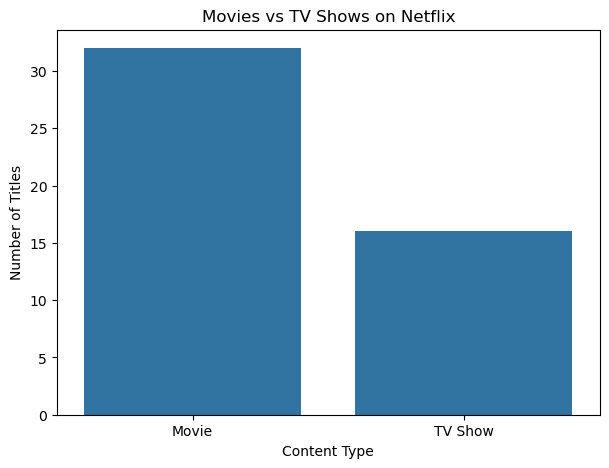

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

In [10]:
# Top 10 ratings/categories
rating_counts = df['rating'].value_counts().head(10)
rating_counts

rating
PG-13        11
TV-14         9
PG            7
TV-PG         5
R             5
TV-G          4
TV-MA         4
Not Rated     2
G             1
Name: count, dtype: int64

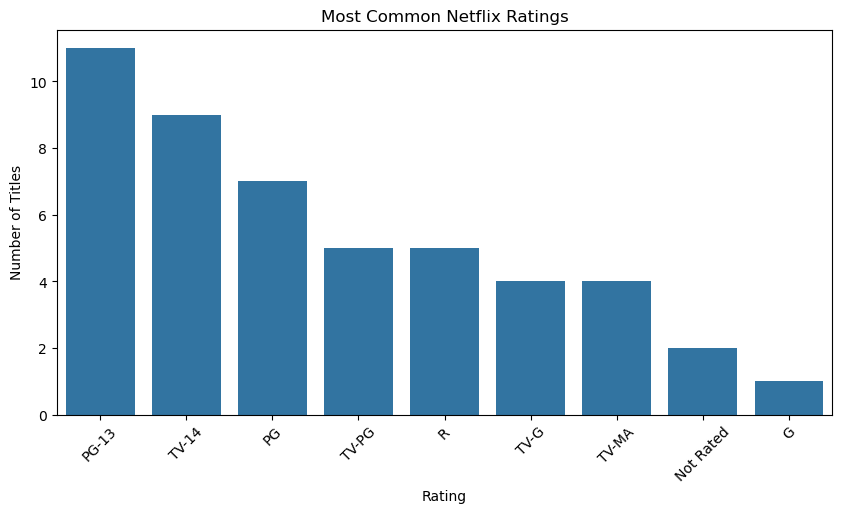

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Most Common Netflix Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

## 5. Release year analysis

In [12]:
# Find the years with the most released content
year_count = df['release_year'].value_counts().sort_index()
year_count.tail(15)

release_year
2016    1
2017    2
2018    3
2019    5
2020    6
2021    8
2022    8
2023    8
2024    7
Name: count, dtype: int64

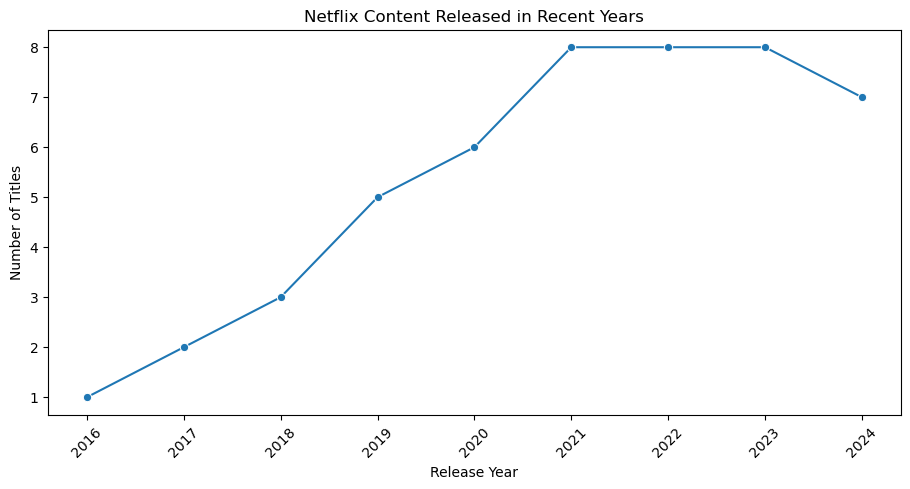

In [13]:
plt.figure(figsize=(11, 5))
sns.lineplot(x=year_count.tail(20).index, y=year_count.tail(20).values, marker='o')
plt.title('Netflix Content Released in Recent Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

## 6. Country analysis

In [14]:
# Count titles by country.
# Some rows contain multiple countries, so take the first listed country.
df['main_country'] = df['country'].str.split(',').str[0].str.strip()

top_countries = df['main_country'].value_counts().head(10)
top_countries

main_country
India             23
United States     13
United Kingdom     4
Canada             4
Australia          4
Name: count, dtype: int64

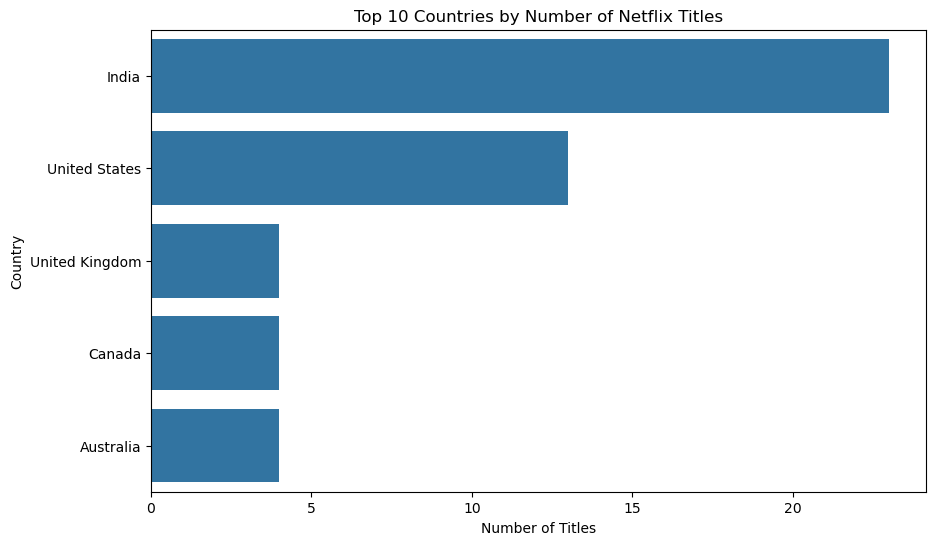

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

## 7. Simple conclusions

In [16]:
print('Total titles:', len(df))
print('Most common content type:', df['type'].mode()[0])
print('Most common rating:', df['rating'].mode()[0])
print('Country with the most titles:', df['main_country'].mode()[0])

Total titles: 48
Most common content type: Movie
Most common rating: PG-13
Country with the most titles: India
